In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Data
df = pd.read_csv("50_Startups.csv")
df = df[['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']]

In [25]:
new_columns = {'R&D Spend': 'rd', 'Marketing Spend': 'ms', 'Administration': 'ad'}
df.rename(columns=new_columns, inplace=True)

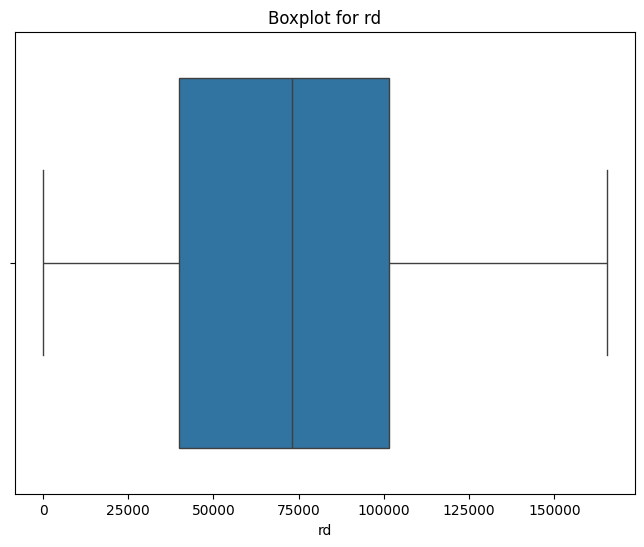

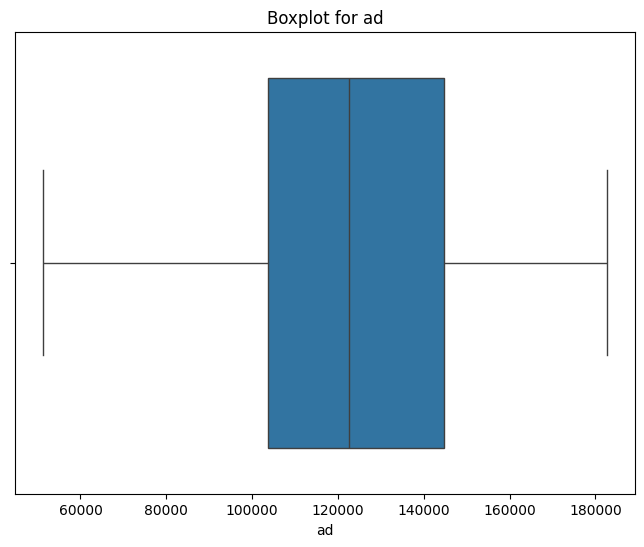

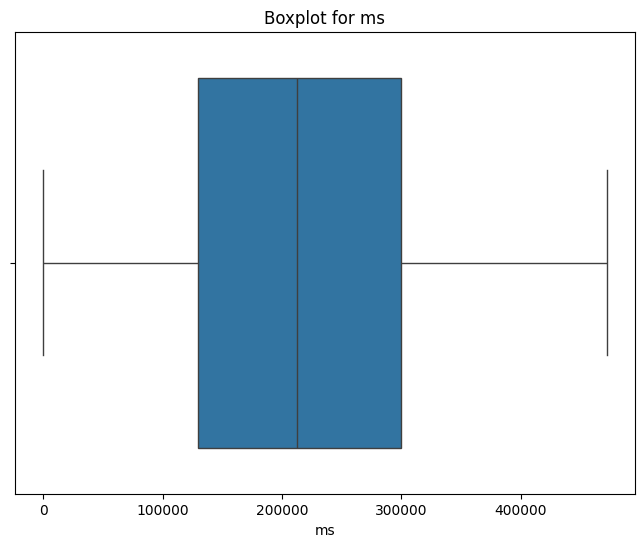

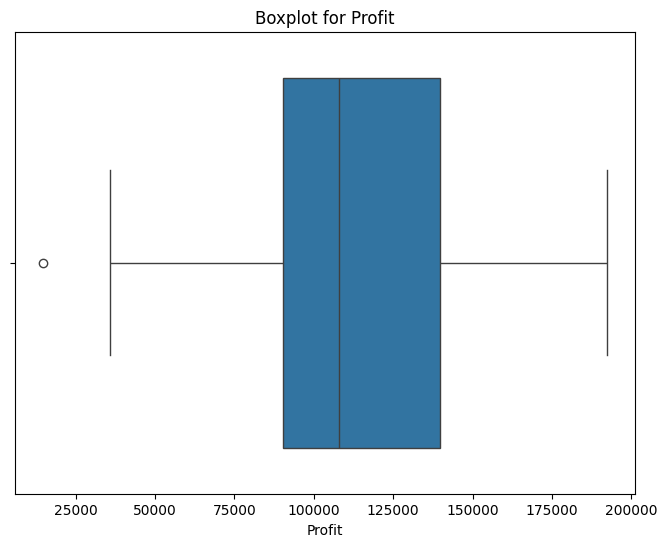

In [26]:
for column in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, data=df)
    plt.title(f'Boxplot for {column}')
    plt.show()


In [27]:
def replace_outliers(data, colname):
    q1 = data[colname].quantile(0.25)
    q3 = data[colname].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)


    outliers = (df[colname] < lower) | (df[colname] > upper)


    df[colname][outliers] = df[colname][outliers].apply(lambda x: upper if x > upper else lower)

    return data

In [28]:
df = replace_outliers(df,'Profit')

In [29]:
# Splitting the variables
Y = df["Profit"]
X = df[['rd', 'ms']]

In [30]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X, Y)

LinearRegression()

In [31]:
Y_pred = LR.predict(X)

In [32]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(Y, Y_pred)
print("Mean Squared Error:", mse.round(3))
print("Root Mean Squared Error:", np.sqrt(mse).round(3))
print("R square:", r2_score(Y, Y_pred).round(3))

Mean Squared Error: 77538492.246
Root Mean Squared Error: 8805.594
R square: 0.951


In [33]:
# Multicollinearity Check
import statsmodels.formula.api as smf
model = smf.ols('Profit ~ rd+ms', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     457.8
Date:                Tue, 13 Feb 2024   Prob (F-statistic):           1.52e-31
Time:                        11:05:00   Log-Likelihood:                -525.10
No. Observations:                  50   AIC:                             1056.
Df Residuals:                      47   BIC:                             1062.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.705e+04   2666.828     17.644      0.0

In [34]:
# VIF Calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

In [35]:
vif_result = calculate_vif(X)
print("VIF Values:")
print(vif_result)

VIF Values:
  Variable       VIF
0       rd  7.156216
1       ms  7.156216


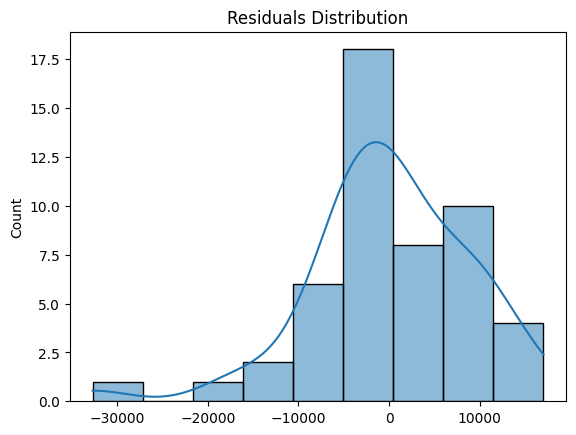

In [36]:
residuals = model.resid
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

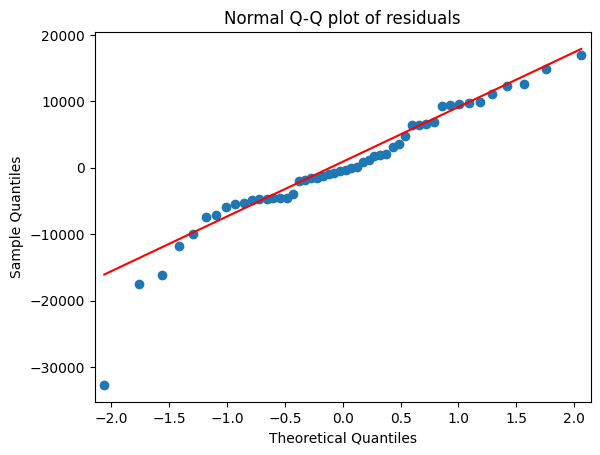

In [37]:
import statsmodels.api as sm
qqplot = sm.qqplot(residuals, line='q')
plt.title("Normal Q-Q plot of residuals")
plt.show()

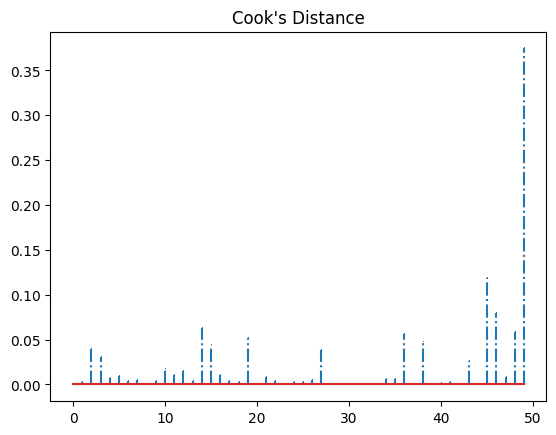

In [38]:
# Cook's Distance
influence = model.get_influence()
cooks_distance = influence.cooks_distance[0]

plt.stem(np.arange(len(cooks_distance)), cooks_distance, markerfmt=",", linefmt="-.")
plt.title("Cook's Distance")
plt.show()

In [39]:
leverage_cutoff = 2 * (X.shape[1] + 1) / X.shape[0]
print("Leverage Cutoff:", leverage_cutoff)

Leverage Cutoff: 0.12


In [40]:
high_leverage_points = np.where(influence.hat_matrix_diag > leverage_cutoff)[0]
print("High Leverage Points:", high_leverage_points)

High Leverage Points: [ 0  6 19 46]


In [41]:
df_cleaned = df.drop(index=high_leverage_points).reset_index(drop=True)


In [42]:
#spiting clean Data
X_cleaned = df_cleaned[['rd', 'ms']]
Y_cleaned = df_cleaned['Profit']


In [43]:
#Spiting data In Train And Test
from sklearn.model_selection import train_test_split
X_train_cleaned, X_test_cleaned, Y_train_cleaned, Y_test_cleaned = train_test_split(X_cleaned, Y_cleaned, test_size=0.3, random_state=0)

In [44]:
# Refiting the model on cleaned data
LR_cleaned = LinearRegression()
LR_cleaned.fit(X_train_cleaned, Y_train_cleaned)

LinearRegression()

In [45]:
Y_pred_cleaned = LR_cleaned.predict(X_test_cleaned)


In [46]:
mse_cleaned = mean_squared_error(Y_test_cleaned, Y_pred_cleaned)
print("Mean Squared Error (Cleaned Model):", mse_cleaned.round(3))
print("Root Mean Squared Error (Cleaned Model):", np.sqrt(mse_cleaned).round(3))
print("R squared (Cleaned Model):", r2_score(Y_test_cleaned, Y_pred_cleaned).round(3))

Mean Squared Error (Cleaned Model): 77416872.954
Root Mean Squared Error (Cleaned Model): 8798.686
R squared (Cleaned Model): 0.917
